<a href="https://colab.research.google.com/github/nbhide8/Bhargava-Lab-Project/blob/main/Barghava_Lab_Project_Basic_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Glossary

**Imaging/pathology-specific**
- **WSI** — Whole-Slide Image. A digitized microscope slide of tissue, scanned at very high resolution.
- **H&E** — Hematoxylin and Eosin. The standard tissue stain combo: hematoxylin stains nuclei dark purple/blue, eosin stains other structures pink.
- **FFPE** — Formalin-Fixed, Paraffin-Embedded. The standard tissue preservation method for diagnostic slides (vs. frozen sections).
- **TIL** — Tumor-Infiltrating Lymphocytes. Immune cells within a tumor; their presence/density is the label we're classifying.
- **DICOM** — Digital Imaging and Communications in Medicine. The standard file format/protocol for medical images, including these WSIs and TIL maps.

**DICOM object types (the "Modality" field)**
- **SM** — Slide Microscopy. The modality code for a whole-slide image object.
- **SEG** — Segmentation. A DICOM object storing a mask/label over an image — here, the TIL present/absent map.
- **ANN** — Annotation. Another DICOM object type storing point/shape annotations (e.g. individual nucleus locations).

**Data source / cohort**
- **IDC** — Imaging Data Commons. The NCI's public cancer imaging repository (accessed here via the `idc-index` package).
- **TCGA** — The Cancer Genome Atlas. A large NCI-led project collecting tissue, imaging, and genomic data across cancer types.
- **LUAD** — Lung Adenocarcinoma. The specific cancer subtype/cohort used here (`tcga_luad`).

**Identifiers**
- **UID** — Unique Identifier. DICOM's long dotted-number IDs (e.g. `SeriesInstanceUID` identifies one series/slide's data).

**ML**
- **CNN** — Convolutional Neural Network. The model architecture used (`TinyCNN`).

# Pipeline Validation: TIL Classification on TCGA-LUAD (2-3 patient scratch run)

**Goal:** prove out the full pipeline — download WSIs and TIL labels from the Imaging Data Commons, tile a whole-slide image, align it with a coarse tumor-infiltrating-lymphocyte (TIL) label map, and run one training/eval loop — on just a couple of patients before scaling to the full validation set.

This notebook is intentionally messy/exploratory in places — including a real bug and a wrong assumption, left in on purpose rather than cleaned up, since seeing what broke and why is part of understanding the pipeline. A clean, formal notebook will be built once this is fully validated.

**Setup:** install the IDC/DICOM libraries and discover the exact download API before using it (rather than guessing method names).

In [ ]:
# idc-index: query/download interface for the NCI Imaging Data Commons (IDC)
# pydicom: read/parse DICOM files (both the whole-slide images and the TIL segmentation masks)
# highdicom: higher-level helpers for DICOM SEG/SR objects (installed for later use)
!pip install -q idc-index pydicom highdicom

from idc_index import index
client = index.IDCClient()

# We don't know the exact download method name yet, so list anything with "download" in it
# rather than guessing and hitting an AttributeError.
print([m for m in dir(client) if 'download' in m.lower()])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.3 MB/s eta 0:00:00
['DOWNLOAD_HIERARCHY_DEFAULT', '_track_download_progress', '_validate_update_manifest_and_get_download_size', 'download_collection', 'download_dicom_instance', 'download_dicom_patients', 'download_dicom_series', 'download_dicom_studies', 'download_from_manifest', 'download_from_selection']


In [ ]:
# Read the docstring before calling it blind - confirms the exact argument names/types
# (seriesInstanceUID, downloadDir) and the default folder-naming template it uses on disk.
help(client.download_dicom_series)

Help on method download_dicom_series in module idc_index.index:

download_dicom_series(
    seriesInstanceUID,
    downloadDir,
    dry_run=False,
    quiet=True,
    show_progress_bar=True,
    use_s5cmd_sync=False,
    dirTemplate='%collection_id/%PatientID/%StudyInstanceUID/%Modality_%SeriesInstanceUID',
    source_bucket_location='aws'
) -> 'None' method of idc_index.index.IDCClient instance
    Download the files corresponding to the seriesInstanceUID to the specified directory.

    Args:
        seriesInstanceUID: string or list of strings containing the values of DICOM SeriesInstanceUID to filter by
        downloadDir: string containing the path to the directory to download the files to
        dry_run: calculates the size of the cohort but download does not start
        quiet (bool): If True, suppresses the output of the subprocess. Defaults to True.
        show_progress_bar (bool): If True, tracks the progress of download
        use_s5cmd_sync (bool): If True, will use s5

### Step 1: Select validation patients

The goal of this notebook is to validate the full pipeline — download → tile a WSI → align it with a TIL label map → train a model — end-to-end on just 2-3 patients, before committing to the full ~50-patient run. Query the IDC metadata index for patients that have **both** an FFPE slide and a binary TIL-presence map (both requirements established in earlier discussion), then pick a starting pair.

In [ ]:
# client.index is the full IDC metadata table (one row per DICOM series, across ALL collections)
df = client.index

# Narrow to: our collection (tcga_luad) + whole-slide microscopy images (Modality == 'SM')
sm_luad = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM')].copy()

# SeriesDescription contains free text like "FFPE HE TP DX1" or "Frozen HE TP BS1".
# We use that to tag specimen prep type - FFPE (formalin-fixed paraffin-embedded, the
# diagnostic-standard prep) vs Frozen section (faster prep, more freezing artifact).
sm_luad['specimen_type'] = sm_luad['SeriesDescription'].apply(
    lambda d: 'FFPE' if isinstance(d, str) and 'FFPE' in d else ('Frozen' if isinstance(d, str) and 'Frozen' in d else 'Other')
)
ffpe_sm = sm_luad[sm_luad['specimen_type'] == 'FFPE']

# TIL (tumor-infiltrating lymphocyte) maps are pre-computed labels published as an IDC
# "analysis result" - no manual annotation needed. We specifically want the *binary*
# present/absent map (there's also a fractional/probability map and a raw CNN-score map).
til_maps = df[(df['collection_id'] == 'tcga_luad') & (df['analysis_result_id'] == 'tcga_sbu_til_maps')]
binary_til = til_maps[til_maps['SeriesDescription'] == 'Stony Brook Inception-V4 Binary TIL Map']

# A usable patient needs BOTH an FFPE slide and a binary TIL map.
eligible = set(ffpe_sm['PatientID']) & set(binary_til['PatientID'])
print("Eligible patients (FFPE slide + binary TIL map):", len(eligible))

# First attempt: pick the 2 smallest-total-size eligible patients for the fastest possible
# end-to-end test. (Spoiler, discovered a few cells down: this is a bad idea - tiny slides
# tend to have very little scanned tissue and near-empty TIL maps.)
per_patient_size = (
    ffpe_sm[ffpe_sm['PatientID'].isin(eligible)].groupby('PatientID')['series_size_MB'].sum()
    + binary_til[binary_til['PatientID'].isin(eligible)].groupby('PatientID')['series_size_MB'].sum()
).sort_values()

chosen_patients = per_patient_size.head(2).index.tolist()
print("Chosen patients:", chosen_patients)
print(per_patient_size.head(2))

Eligible patients (FFPE slide + binary TIL map): 478
Chosen patients: ['TCGA-05-4425', 'TCGA-05-5715']
PatientID
TCGA-05-4425    7.728642
TCGA-05-5715    9.352530
Name: series_size_MB, dtype: float64


### Get the exact series identifiers to download

In [ ]:
import pydicom, glob, os
print("imports ready")

imports ready


In [ ]:
# Pull the exact SeriesInstanceUID for each chosen patient's FFPE slide and TIL map -
# download_dicom_series() downloads by series UID, not by patient ID.
sm_series = ffpe_sm[ffpe_sm['PatientID'].isin(chosen_patients)][['PatientID', 'SeriesInstanceUID', 'series_size_MB']]
til_series = binary_til[binary_til['PatientID'].isin(chosen_patients)][['PatientID', 'SeriesInstanceUID', 'series_size_MB']]
print(sm_series)
print(til_series)

all_series_uids = sm_series['SeriesInstanceUID'].tolist() + til_series['SeriesInstanceUID'].tolist()
print(all_series_uids)

           PatientID                                  SeriesInstanceUID  \
982217  TCGA-55-8203  1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637...   
983565  TCGA-86-8671  1.3.6.1.4.1.5962.99.1.1066847957.103275808.163...   

        series_size_MB  
982217       75.304214  
983565      100.026984  
           PatientID                                  SeriesInstanceUID  \
982213  TCGA-55-8203  1.2.826.0.1.3680043.10.511.3.49449816188743726...   
983561  TCGA-86-8671  1.2.826.0.1.3680043.10.511.3.31398648032487910...   

        series_size_MB  
982213        0.013342  
983561        0.014442  
['1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0', '1.3.6.1.4.1.5962.99.1.1066847957.103275808.1637449420501.2.0', '1.2.826.0.1.3680043.10.511.3.494498161887437263625724289750573', '1.2.826.0.1.3680043.10.511.3.31398648032487910057586316915551171']


### Download the DICOM files locally

In [ ]:
# Download to Colab's local (ephemeral) disk, not Drive - much faster I/O for this kind of
# repeated read/tile workload, at the cost of losing the files when the runtime recycles.
download_dir = '/content/validation_data'
client.download_dicom_series(all_series_uids, download_dir)

# Confirm what actually landed on disk and in what folder structure (matches the
# %collection_id/%PatientID/%StudyInstanceUID/%Modality_%SeriesInstanceUID template from help() above)
import subprocess
print(subprocess.run(['find', download_dir, '-type', 'f'], capture_output=True, text=True).stdout)

/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SEG_1.2.826.0.1.3680043.10.511.3.494498161887437263625724289750573/a11963f9-ce89-4afa-87c7-5acb2d20a84d.dcm
/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SM_1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0/c0fa492d-da8d-41f8-8aad-a42db1ace8a2.dcm
/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SM_1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0/1a81fc65-f759-499d-a554-440bf695706d.dcm
/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SM_1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0/7424ab63-a7d7-428c-b56f-0e6f3d698ee4.dcm
/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SM_1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0/8302383e-aeab-4dbd-8ebb-d58ea4d39396.dcm
/content/va

### First look at the TIL map — a surprise

Going in, the assumption was that the TIL SEG object would have many frames — one per spatial tile, each with its own position metadata (`PlanePositionSlideSequence`) that we'd need to match against the WSI's tile grid, similar to how the WSI pyramid itself is tiled.

That assumption was wrong, and it's worth showing the wrong turn rather than hiding it: the code below tries to iterate `PerFrameFunctionalGroupsSequence` and crashes with an `AttributeError`, because `NumberOfFrames` is actually just **1**. The next few cells investigate what the TIL map's structure actually is — and it turns out to be much simpler (see below) — plus we discover the first two chosen patients have almost no TIL-positive tissue at all, which prompts a change in selection strategy a bit further down.

In [ ]:
import pydicom
import glob

seg_path = glob.glob(f'{download_dir}/tcga_luad/TCGA-05-4425/*/SEG_*/*.dcm')[0]
seg = pydicom.dcmread(seg_path)

print("Modality:", seg.Modality)
print("Rows x Cols per frame:", seg.Rows, seg.Columns)
print("Number of frames:", seg.NumberOfFrames)
print("Segments:")
for s in seg.SegmentSequence:
    print("  ", s.SegmentLabel, "| value:", s.SegmentNumber)

# Shared geometry (applies to all frames)
shared = seg.SharedFunctionalGroupsSequence[0]
print("\nShared PixelMeasures:", shared.PixelMeasuresSequence[0].PixelSpacing if hasattr(shared, 'PixelMeasuresSequence') else "N/A")

# Assumption going in: a SEG object with MANY frames, one per tile, each carrying its own
# spatial position (PlanePositionSlideSequence) that we'd need to match against the WSI's
# tile grid. Trying to print the first 3 frames' positions to see that structure...
print("\nFirst 3 frames' plane position:")
for f in seg.PerFrameFunctionalGroupsSequence[:3]:
    pos = f.PlanePositionSlideSequence[0]
    print("  x_offset:", pos.XOffsetInSlideCoordinateSystem, "y_offset:", pos.YOffsetInSlideCoordinateSystem,
          "col_pos:", getattr(pos, 'ColumnPositionInTotalImagePixelMatrix', None),
          "row_pos:", getattr(pos, 'RowPositionInTotalImagePixelMatrix', None))
# ^ This raises AttributeError below: NumberOfFrames was 1, so there's no
# PerFrameFunctionalGroupsSequence at all. The map is simpler than expected - see next cell.

Modality: SEG
Rows x Cols per frame: 23 50
Number of frames: 1
Segments:
   TILs Present | value: 1

Shared PixelMeasures: [0.05, 0.05]

First 3 frames' plane position:


AttributeError: 'FileDataset' object has no attribute 'PerFrameFunctionalGroupsSequence'

In [ ]:
# Since it's a single frame, check whether it uses the same TotalPixelMatrix + origin
# convention as the WSI object (same pattern we saw when inspecting the SM slide earlier).
geometry_tags = ['TotalPixelMatrixColumns', 'TotalPixelMatrixRows', 'TotalPixelMatrixOriginSequence',
                  'ImageOrientationSlide', 'DimensionOrganizationType', 'NumberOfFrames']
for tag in geometry_tags:
    print(tag, ':', getattr(seg, tag, 'NOT PRESENT'))

print()
print("Pixel array shape:", seg.pixel_array.shape)
# All zero here - this patient's TIL map has no "present" pixels at all (foreshadows the
# near-empty-tissue problem with picking the smallest-file-size slides).
print("Unique values in pixel array:", set(seg.pixel_array.flatten().tolist()))

TotalPixelMatrixColumns : 50
TotalPixelMatrixRows : 23
TotalPixelMatrixOriginSequence : [(0040,072A) X Offset in Slide Coordinate System DS: '0.0'
(0040,073A) Y Offset in Slide Coordinate System DS: '0.0'
(0040,074A) Z Offset in Slide Coordinate System DS: '0.0']
ImageOrientationSlide : [0, -1, 0, -1, 0, 0]
DimensionOrganizationType : TILED_FULL
NumberOfFrames : 1

Pixel array shape: (23, 50)
Unique values in pixel array: {0}


In [ ]:
# Check whether the second chosen patient's TIL map is any more useful.
# Finding: no - both of the two smallest-file-size patients have almost no positive TIL area.
seg_path_2 = glob.glob(f'{download_dir}/tcga_luad/TCGA-05-5715/*/SEG_*/*.dcm')[0]
seg2 = pydicom.dcmread(seg_path_2)
print("Patient 2 SEG shape:", seg2.pixel_array.shape, "nonzero pixels:", seg2.pixel_array.sum())
print("Patient 1 SEG shape:", seg.pixel_array.shape, "nonzero pixels:", seg.pixel_array.sum())

Patient 2 SEG shape: (50, 42) nonzero pixels: 1
Patient 1 SEG shape: (23, 50) nonzero pixels: 0


### Course correction: scout cheaply before committing

The first patient selection (smallest total file size) turned out to be a bad heuristic — it gave us near-empty TIL maps. Since the SEG files are tiny (~10KB, just a coarse binary mask), we can afford to download SEG maps for **many** candidate patients and check their label balance before spending time/bandwidth on the much larger WSI downloads.

In [ ]:
# Course correction: picking by smallest total file size gave us near-empty TIL maps.
# TIL SEG files are tiny (~10KB each, since they're just a coarse binary mask), so we can
# cheaply download SEG maps for MANY candidate patients, inspect their label balance, and
# only THEN download the (much larger) full-resolution WSI for the ones that look good.

# Candidate pool: eligible patients with reasonably small SM slides (keeps later tiling fast),
# but not the absolute smallest (those tend to have near-empty tissue/TIL maps).
per_patient_sm_size = ffpe_sm[ffpe_sm['PatientID'].isin(eligible)].groupby('PatientID')['series_size_MB'].sum().sort_values()
candidates = per_patient_sm_size.iloc[20:50].index.tolist()  # skip the tiniest 20, take the next 30
print(f"{len(candidates)} candidates, SM size range: {per_patient_sm_size.loc[candidates].min():.1f}-{per_patient_sm_size.loc[candidates].max():.1f} MB")

candidate_til_uids = binary_til[binary_til['PatientID'].isin(candidates)]['SeriesInstanceUID'].tolist()
til_scout_dir = '/content/til_scout'
client.download_dicom_series(candidate_til_uids, til_scout_dir)

30 candidates, SM size range: 66.3-114.6 MB


### Rank candidates by label balance

Score each candidate by how close its TIL-positive fraction is to ~30%. A slide that's almost entirely one class isn't a good test of whether the pipeline actually distinguishes the two — we want visible variety.

In [ ]:
import os

results = []
for patient in candidates:
    seg_files = glob.glob(f'{til_scout_dir}/tcga_luad/{patient}/*/SEG_*/*.dcm')
    if not seg_files:
        continue
    d = pydicom.dcmread(seg_files[0])
    arr = d.pixel_array
    frac_positive = arr.mean()  # array is 0/1, so the mean IS directly the positive fraction
    results.append((patient, arr.shape, frac_positive))

# Sort candidates by how close their positive fraction is to ~30% - a middling balance is
# more useful for validating the pipeline visually than an almost-all-one-class slide.
results.sort(key=lambda r: abs(r[2] - 0.3))
for r in results[:10]:
    print(r)

('TCGA-86-8671', (170, 154), np.float64(0.32215431627196334))
('TCGA-55-8203', (88, 193), np.float64(0.16268252472915684))
('TCGA-55-8092', (113, 164), np.float64(0.13366069501402977))
('TCGA-55-8301', (82, 88), np.float64(0.11031042128603104))
('TCGA-55-8097', (106, 154), np.float64(0.09611614800294045))
('TCGA-55-7914', (146, 154), np.float64(0.09291051414339085))
('TCGA-44-3919', (349, 111), np.float64(0.08836056687059553))
('TCGA-55-7726', (156, 169), np.float64(0.0760886056744045))
('TCGA-55-7725', (142, 149), np.float64(0.07269118064089233))
('TCGA-55-8085', (101, 159), np.float64(0.06806152313344542))


### Finalize patient selection and download

Based on the scouting pass, `TCGA-86-8671` (~32% TIL-positive) and `TCGA-55-8203` (~16% TIL-positive) give a reasonable mix of both classes. Now download their *full* data — the WSI slide, not just the tiny SEG map.

In [ ]:
# Final patient choice, based on the scouting above: one moderately TIL-dense slide (~32%)
# and one sparser one (~16%) - now download their FULL data (WSI + TIL map, not just SEG).
chosen_patients = ['TCGA-86-8671', 'TCGA-55-8203']

sm_uids = ffpe_sm[ffpe_sm['PatientID'].isin(chosen_patients)]['SeriesInstanceUID'].tolist()
til_uids = binary_til[binary_til['PatientID'].isin(chosen_patients)]['SeriesInstanceUID'].tolist()

download_dir = '/content/validation_data'  # reusing the same dir as before; new files just add to it
client.download_dicom_series(sm_uids + til_uids, download_dir)

for p in chosen_patients:
    print(p, glob.glob(f'{download_dir}/tcga_luad/{p}/*/*'))

TCGA-86-8671 ['/content/validation_data/tcga_luad/TCGA-86-8671/2.25.235766494686944987075832985212359647004/SEG_1.2.826.0.1.3680043.10.511.3.31398648032487910057586316915551171', '/content/validation_data/tcga_luad/TCGA-86-8671/2.25.235766494686944987075832985212359647004/SM_1.3.6.1.4.1.5962.99.1.1066847957.103275808.1637449420501.2.0']
TCGA-55-8203 ['/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SEG_1.2.826.0.1.3680043.10.511.3.494498161887437263625724289750573', '/content/validation_data/tcga_luad/TCGA-55-8203/2.25.191487759460113220763928239323574310408/SM_1.3.6.1.4.1.5962.99.1.1056075350.89292293.1637438647894.2.0']


### Choose a working resolution level

Each WSI is stored as a DICOM "pyramid" — several resolution levels of the same slide bundled together. Before tiling anything, inspect what's available: the full-resolution level is too large to decode into memory in one shot, and the thumbnail is far too coarse to produce meaningful patches.

In [ ]:
# Each WSI ships as a DICOM "pyramid": several resolution levels of the same slide, all in
# the same folder. Read all of them in (sm_files) and print size/spacing for each - the
# full-res level is way too large to hold in memory, the thumbnail is too coarse.
sm_dir = glob.glob(f'{download_dir}/tcga_luad/TCGA-86-8671/*/SM_*')[0]
sm_files = [pydicom.dcmread(os.path.join(sm_dir, f)) for f in os.listdir(sm_dir)]
for d in sm_files:
    spacing = d.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing
    print(f"{d.filename}: {d.TotalPixelMatrixColumns}x{d.TotalPixelMatrixRows}, "
          f"pixel_spacing={spacing}, frames={d.NumberOfFrames}, image_type={list(d.ImageType)}")

/content/validation_data/tcga_luad/TCGA-86-8671/2.25.235766494686944987075832985212359647004/SM_1.3.6.1.4.1.5962.99.1.1066847957.103275808.1637449420501.2.0/7876d125-ab91-4b39-ba2b-9ce6b179a3be.dcm: 1918x2117, pixel_spacing=[.004032919708029, .004032919708029], frames=72, image_type=['DERIVED', 'PRIMARY', 'VOLUME', 'RESAMPLED']
/content/validation_data/tcga_luad/TCGA-86-8671/2.25.235766494686944987075832985212359647004/SM_1.3.6.1.4.1.5962.99.1.1066847957.103275808.1637449420501.2.0/03f1ad19-a669-42d1-acb6-fe5608272900.dcm: 695x768, pixel_spacing=[.011129697841727, .011129697841727], frames=1, image_type=['DERIVED', 'PRIMARY', 'THUMBNAIL', 'RESAMPLED']
/content/validation_data/tcga_luad/TCGA-86-8671/2.25.235766494686944987075832985212359647004/SM_1.3.6.1.4.1.5962.99.1.1066847957.103275808.1637449420501.2.0/e7c4aee1-4bcf-4aca-acd2-f5a000705e5b.dcm: 7673x8469, pixel_spacing=[.001008098527304, .001008098527304], frames=1020, image_type=['DERIVED', 'PRIMARY', 'VOLUME', 'RESAMPLED']
/content

### Reconstruct a full-resolution image from tiled DICOM frames

WSI DICOM files store the image as many small tiled frames (e.g. 256×256), not one contiguous array — `assemble_tiled_image()` decodes all frames and stitches them into a single numpy array in the correct grid order (`TILED_FULL` orders frames row-major).

The pyramid level chosen here (~1 micron/pixel) is deliberate: each 50-micron TIL-map tile then corresponds to roughly a 50×50 pixel patch — large enough to be a meaningful image, small enough that decoding the whole level fits comfortably in memory (unlike the full-resolution level, which would be several GB).

In [ ]:
import numpy as np

def assemble_tiled_image(ds):
    """Reconstruct a full WSI pyramid level from a TILED_FULL multi-frame DICOM into one numpy array."""
    frames = ds.pixel_array  # (num_frames, tile_rows, tile_cols, 3) - pydicom decodes every frame at once
    tile_rows, tile_cols = ds.Rows, ds.Columns  # size of ONE tile, e.g. 256x256
    total_rows, total_cols = ds.TotalPixelMatrixRows, ds.TotalPixelMatrixColumns  # size of the full level
    n_tile_cols = -(-total_cols // tile_cols)  # ceil division: tiles needed per row
    n_tile_rows = -(-total_rows // tile_rows)  # tile-rows needed total
    # Canvas is padded up to a whole number of tiles; cropped back to the true size at the end.
    canvas = np.zeros((n_tile_rows * tile_rows, n_tile_cols * tile_cols, 3), dtype=np.uint8)
    for idx in range(frames.shape[0]):
        # TILED_FULL orders frames row-major: column index increases fastest, then row.
        r, c = divmod(idx, n_tile_cols)
        canvas[r*tile_rows:(r+1)*tile_rows, c*tile_cols:(c+1)*tile_cols] = frames[idx]
    return canvas[:total_rows, :total_cols]

# Pick the ~1 micron/pixel level: gives ~50x50 pixel patches per 50-micron TIL tile
# (50 micron TIL-tile / ~1 micron per WSI pixel ≈ 50 pixels/side - a reasonably sized patch).
# Sort non-thumbnail levels by size and take the second-smallest.
volume_levels = sorted(
    (d for d in sm_files if 'THUMBNAIL' not in d.ImageType),
    key=lambda d: d.TotalPixelMatrixColumns
)
level = volume_levels[1]
print("Chosen level:", level.TotalPixelMatrixColumns, "x", level.TotalPixelMatrixRows,
      "pixel spacing:", level.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing)

wsi_img = assemble_tiled_image(level)
print("Assembled image shape:", wsi_img.shape)

Chosen level: 7673 x 8469 pixel spacing: [.001008098527304, .001008098527304]
Assembled image shape: (8469, 7673, 3)


**Figure: reconstructed WSI level preview**

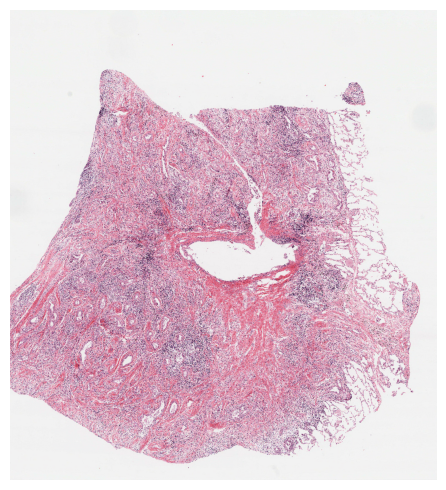

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
downsample = 8
ax.imshow(wsi_img[::downsample, ::downsample])
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/wsi_preview.png', dpi=80)
plt.show()

### Extract patches aligned to the TIL grid — and a bug along the way

Since both the SEG object and the chosen WSI level share the same slide coordinate origin `(0, 0)` (confirmed a few cells back), alignment reduces to matching physical distances via each object's pixel spacing — `scale = seg_spacing / wsi_spacing` tells us how many WSI pixels correspond to one TIL-map pixel.

**Bug hit here on the first pass:** `scale` (≈49.6) isn't an integer, so computing crop boundaries as `int(row * scale)` produced patches that varied by ±1 pixel in size — `np.stack(patches)` then failed with a shape error. Fixed by always resizing each crop to a fixed `PATCH_SIZE`, which is what a real pipeline needs anyway (models need consistent input dimensions).

**Figure: TIL map overlaid on the tissue thumbnail**

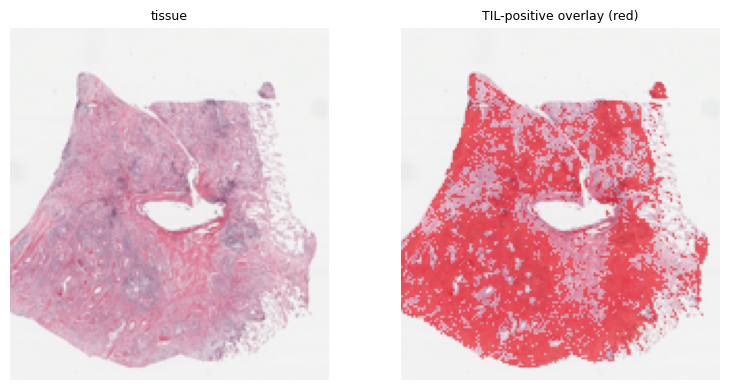

In [ ]:
from PIL import Image

thumbnail = np.array(Image.fromarray(wsi_img).resize((til_map.shape[1], til_map.shape[0])))
overlay = thumbnail.copy()
overlay[til_map == 1] = [255, 0, 0]
blended = (0.5 * thumbnail + 0.5 * overlay).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(thumbnail)
axes[0].set_title('tissue', fontsize=9)
axes[0].axis('off')
axes[1].imshow(blended)
axes[1].set_title('TIL-positive overlay (red)', fontsize=9)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('/content/til_overlay.png', dpi=80)
plt.show()

In [ ]:
from PIL import Image

PATCH_SIZE = 64  # fixed output size fed to the model, regardless of raw crop size - this also
                  # fixes a rounding bug (hit on the first attempt below): crop sizes varied by
                  # ±1 pixel because `scale` isn't an integer, so we always resize to a canonical size.

seg_path = glob.glob(f'{download_dir}/tcga_luad/TCGA-86-8671/*/SEG_*/*.dcm')[0]
seg = pydicom.dcmread(seg_path)
til_map = seg.pixel_array  # (til_rows, til_cols), binary

# Both the SEG map and the chosen WSI level share the same slide coordinate origin (0,0) -
# confirmed earlier when we saw TotalPixelMatrixOriginSequence = (0,0,0) on both objects.
# That means alignment is just a matter of matching physical distances via each object's
# pixel spacing - no need to deal with per-frame plane positions (this map is single-frame).
seg_spacing = float(seg.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])  # mm/pixel, e.g. 0.05
wsi_spacing = float(level.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])
scale = seg_spacing / wsi_spacing  # how many WSI pixels per TIL-map pixel
print(f"TIL map: {til_map.shape}, spacing {seg_spacing}mm/px. WSI level spacing {wsi_spacing}mm/px. Scale: {scale:.1f}")

patches, labels = [], []
for row in range(til_map.shape[0]):
    for col in range(til_map.shape[1]):
        # Each TIL-map pixel (row, col) covers a scale x scale pixel box in the WSI level.
        y0, y1 = int(row * scale), int((row + 1) * scale)
        x0, x1 = int(col * scale), int((col + 1) * scale)
        if y1 > wsi_img.shape[0] or x1 > wsi_img.shape[1]:
            continue  # TIL map can extend slightly past our reconstructed canvas; skip those edges
        crop = wsi_img[y0:y1, x0:x1]
        # Filter on TEXTURE, not raw brightness: blank/background regions - whether the black
        # canvas padding OR real non-tissue glass area (which is near-WHITE, not black) - are
        # both nearly uniform (low std). Real tissue always has texture regardless of stain
        # intensity. (Originally used `crop.mean() < 5`, which only caught the black padding
        # and let ~60% of "TIL absent" patches through as blank glass - see diagnostic above.)
        if crop.std() < 10:
            continue
        patch = np.array(Image.fromarray(crop).resize((PATCH_SIZE, PATCH_SIZE)))
        patches.append(patch)
        labels.append(int(til_map[row, col]))

patches = np.stack(patches)
labels = np.array(labels)
print(f"Extracted {len(patches)} patches, shape {patches.shape}. Positive: {labels.sum()}, Negative: {(labels == 0).sum()}")

TIL map: (170, 154), spacing 0.05mm/px. WSI level spacing 0.001008098527304mm/px. Scale: 49.6
Extracted 15009 patches, shape (15009, 64, 64, 3). Positive: 8434, Negative: 6575


### Visual sanity check

Before trusting these labels for training, look at a few patches directly. This is the cheapest way to catch a coordinate bug (e.g. flipped rows/columns) before it silently corrupts a much bigger run later. (Note: the rendered image is large — view it directly in the Colab output below rather than relying on it round-tripping through the assistant's tool output, which hit a size limit here.)

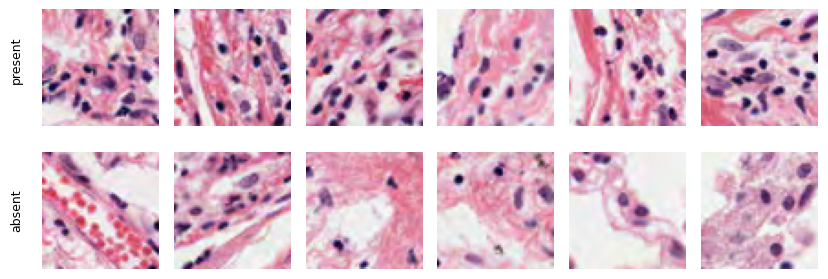

In [ ]:
import matplotlib.pyplot as plt

# Visually confirm labels look correct before trusting them for training - the cheapest way
# to catch a coordinate bug (e.g. flipped rows/cols) before it silently corrupts a bigger run.
rng = np.random.default_rng(0)
n_per_class = 6
pos_idx = rng.choice(np.where(labels == 1)[0], n_per_class, replace=False)
neg_idx = rng.choice(np.where(labels == 0)[0], n_per_class, replace=False)

fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 1.4, 3.2))
for ax, idx in zip(axes[0], pos_idx):
    ax.imshow(patches[idx])
    ax.axis('off')
for ax, idx in zip(axes[1], neg_idx):
    ax.imshow(patches[idx])
    ax.axis('off')
fig.text(0.02, 0.75, 'present', rotation=90, va='center', fontsize=9)
fig.text(0.02, 0.28, 'absent', rotation=90, va='center', fontsize=9)
plt.tight_layout(rect=[0.04, 0, 1, 1])
plt.savefig('/content/patch_sanity_check.png', dpi=80)
plt.show()

### Quantitative sanity check

A second, independent check alongside the visual one. TIL-dense tissue is packed with small, darkly-stained lymphocyte nuclei — so if the alignment is correct, "present" patches should look measurably darker than "absent" patches under H&E staining. This isn't proof, but it's real biological signal that would be very unlikely to appear by chance from a coordinate bug.

In [ ]:
# A second, quantitative sanity check alongside the visual one: TIL-dense regions are
# packed with small, densely-stained lymphocyte nuclei, which biologically should look
# darker/more purple under H&E staining than surrounding tissue. If "present" patches
# come out reliably darker than "absent" ones, that's independent evidence the coordinate
# alignment is actually correct - not just a coincidence.
pos_patches = patches[labels == 1]
neg_patches = patches[labels == 0]

print("Positive patches - mean brightness:", pos_patches.mean(), "std across patches:", pos_patches.mean(axis=(1,2,3)).std())
print("Negative patches - mean brightness:", neg_patches.mean(), "std across patches:", neg_patches.mean(axis=(1,2,3)).std())
# Also rule out a degenerate bug where every "patch" is actually the same crop repeated.
print("Are any patches identical (bug check)?", len({p.tobytes() for p in patches[:200]}) < 200)

Positive patches - mean brightness: 180.57372083898383 std across patches: 13.08921923317844
Negative patches - mean brightness: 195.0155894526299 std across patches: 21.692450619077444
Are any patches identical (bug check)? False


### Package the pipeline into a reusable function

Everything validated on one patient above (assemble WSI level → align with TIL grid → extract fixed-size patches) gets wrapped into `extract_patches_for_patient()` and run on both chosen patients. Each patch is tagged with its source `PatientID` — needed for the patient-level split in the next step.

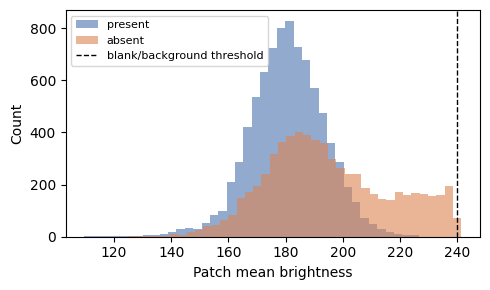

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(pos_patches.mean(axis=(1,2,3)), bins=40, alpha=0.6, label='present', color='#4C72B0')
ax.hist(neg_patches.mean(axis=(1,2,3)), bins=40, alpha=0.6, label='absent', color='#DD8452')
ax.axvline(240, color='black', linestyle='--', linewidth=1, label='blank/background threshold')
ax.set_xlabel('Patch mean brightness')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/brightness_histogram.png', dpi=80)
plt.show()

In [ ]:
def extract_patches_for_patient(patient_id, download_dir, patch_size=64):
    """Repeat the validated single-patient extraction pipeline (cells above) as a reusable function."""
    sm_dir = glob.glob(f'{download_dir}/tcga_luad/{patient_id}/*/SM_*')[0]
    sm_files = [pydicom.dcmread(os.path.join(sm_dir, f)) for f in os.listdir(sm_dir)]
    volume_levels = sorted((d for d in sm_files if 'THUMBNAIL' not in d.ImageType),
                            key=lambda d: d.TotalPixelMatrixColumns)
    level = volume_levels[1]  # ~1 micron/pixel level
    wsi_img = assemble_tiled_image(level)

    seg_path = glob.glob(f'{download_dir}/tcga_luad/{patient_id}/*/SEG_*/*.dcm')[0]
    seg = pydicom.dcmread(seg_path)
    til_map = seg.pixel_array

    seg_spacing = float(seg.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])
    wsi_spacing = float(level.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])
    scale = seg_spacing / wsi_spacing

    patches, labels = [], []
    for row in range(til_map.shape[0]):
        for col in range(til_map.shape[1]):
            y0, y1 = int(row * scale), int((row + 1) * scale)
            x0, x1 = int(col * scale), int((col + 1) * scale)
            if y1 > wsi_img.shape[0] or x1 > wsi_img.shape[1]:
                continue
            crop = wsi_img[y0:y1, x0:x1]
            # Texture-based tissue filter (see fix above): excludes both black canvas padding
            # AND near-white blank glass background, unlike a raw-brightness check.
            if crop.std() < 10:
                continue
            patch = np.array(Image.fromarray(crop).resize((patch_size, patch_size)))
            patches.append(patch)
            labels.append(int(til_map[row, col]))

    return np.stack(patches), np.array(labels)

all_patches, all_labels, patient_ids = [], [], []
for p in chosen_patients:
    pat_patches, pat_labels = extract_patches_for_patient(p, download_dir)
    all_patches.append(pat_patches)
    all_labels.append(pat_labels)
    patient_ids.append(np.full(len(pat_labels), p))  # tag every patch with its source patient - needed for the patient-level split next
    print(p, pat_patches.shape, "positive rate:", pat_labels.mean())

all_patches = np.concatenate(all_patches)
all_labels = np.concatenate(all_labels)
patient_ids = np.concatenate(patient_ids)
print("Total:", all_patches.shape, all_labels.shape)

TCGA-86-8671 (15009, 64, 64, 3) positive rate: 0.5619295089612899
TCGA-55-8203 (8841, 64, 64, 3) positive rate: 0.31252120800814387
Total: (23850, 64, 64, 3) (23850,)


### Build the dataset — with a patient-level split

This is the most important methodological choice in the whole pipeline: the train/test split is **by patient**, not by random patch. Patches from the same slide share staining batch, scanner, and patient biology — a random patch-level split would let the model "memorize" slide-specific quirks rather than learn the actual TIL signal, and the resulting accuracy would be misleadingly high. Train on `TCGA-86-8671` entirely, test on `TCGA-55-8203` entirely.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Patient-level split, not a random patch-level split: all patches from one WSI are highly
# correlated (same stain batch, same scanner, same patient biology), so if patches from the
# same slide ended up in both train and test, the model could "cheat" by recognizing the
# slide itself rather than learning the TIL signal. Train on one whole patient, test on the other.
train_mask = patient_ids == 'TCGA-86-8671'
test_mask = patient_ids == 'TCGA-55-8203'

class PatchDataset(Dataset):
    def __init__(self, patches, labels):
        self.patches = patches
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        # HWC uint8 [0,255] -> CHW float [0,1]: the layout/format PyTorch conv layers expect
        img = torch.from_numpy(self.patches[idx]).float().permute(2, 0, 1) / 255.0
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = PatchDataset(all_patches[train_mask], all_labels[train_mask])
test_ds = PatchDataset(all_patches[test_mask], all_labels[test_mask])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)  # no need to shuffle at eval time

print(f"Train (TCGA-86-8671): {len(train_ds)} patches. Test (TCGA-55-8203): {len(test_ds)} patches.")
print(f"Train positive rate: {all_labels[train_mask].mean():.2f}. Test positive rate: {all_labels[test_mask].mean():.2f}")

Train (TCGA-86-8671): 15009 patches. Test (TCGA-55-8203): 8841 patches.
Train positive rate: 0.56. Test positive rate: 0.31


### Tiny CNN + training loop

This is a **plumbing test, not a real experiment**. The goal is only to confirm that data flows correctly through a model — forward pass, loss computation, backward pass, optimizer step — and that the loss actually decreases. The architecture is intentionally minimal (3 conv layers) and only trains for 3 epochs.

**Figure: patch class balance, train vs. test**

In [ ]:
counts = {
    'train\npresent': all_labels[train_mask].sum(),
    'train\nabsent': (all_labels[train_mask] == 0).sum(),
    'test\npresent': all_labels[test_mask].sum(),
    'test\nabsent': (all_labels[test_mask] == 0).sum(),
}
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.keys(), counts.values(), color=['#4C72B0', '#DD8452', '#4C72B0', '#DD8452'])
ax.set_ylabel('Patch count')
plt.tight_layout()
plt.savefig('/content/class_balance.png', dpi=80)
plt.show()

In [ ]:
class TinyCNN(nn.Module):
    """A deliberately small CNN - the point here is to confirm the training loop runs
    correctly (data loads, forward/backward pass, loss decreases), not to get a good model."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),  # -> 1x1 regardless of input size
        )
        self.classifier = nn.Linear(64, 1)  # single logit: binary TIL present/absent

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TinyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()  # combines sigmoid + binary cross-entropy in one numerically stable op

epoch_losses = []
for epoch in range(3):  # just enough epochs to see the loss trend, not to converge
    model.train()
    total_loss = 0
    for imgs, labels_batch in train_loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)  # un-average the per-batch loss so we can average correctly over the whole dataset
    avg_loss = total_loss / len(train_ds)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: train loss = {avg_loss:.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='#4C72B0')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train loss')
ax.set_xticks(range(1, len(epoch_losses) + 1))
plt.tight_layout()
plt.savefig('/content/loss_curve.png', dpi=80)
plt.show()

Epoch 1: train loss = 0.2973
Epoch 2: train loss = 0.2389
Epoch 3: train loss = 0.2247


### Evaluate and interpret honestly

The number below isn't meant to be a real result — read it as a diagnostic, not a verdict.

Watch for whether it beats the **majority-class baseline** (always predicting "absent"). If it doesn't, that's *expected* at this scale, not a sign of a bug: this model trained on exactly **one** slide, for 3 epochs, with a tiny CNN and no class-imbalance handling. None of that is enough to generalize to a different patient's staining and tissue characteristics — that's exactly why the real run needs ~50 patients, not 2.

In [ ]:
model.eval()
correct, total, test_loss = 0, 0, 0
with torch.no_grad():  # no need to track gradients during evaluation - saves memory/compute
    for imgs, labels_batch in test_loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels_batch)
        test_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()  # convert logit -> probability -> binary prediction
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

print(f"Test loss: {test_loss / total:.4f}")
print(f"Test accuracy: {correct / total:.4f}")
# Compare against the "dumbest possible" baseline: always predicting the majority class.
# A real model needs to beat THIS, not just get "high" accuracy in isolation.
print(f"Majority-class baseline accuracy (always predict 'absent'): {1 - all_labels[test_mask].mean():.4f}")